In [3]:
import pandas as pd #pandas is a library used to handle table dataset, imported it as "pd" alias name

dataset = pd.read_csv("Salary_Data.csv") #CSV file is loaded as dataframe, using the function read_csv in pandas, file should be in same folder
dataset

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [5]:
independent = dataset[["YearsExperience"]] # the independent variable X-values are taken from datasetbb
independent

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2
5,2.9
6,3.0
7,3.2
8,3.2
9,3.7


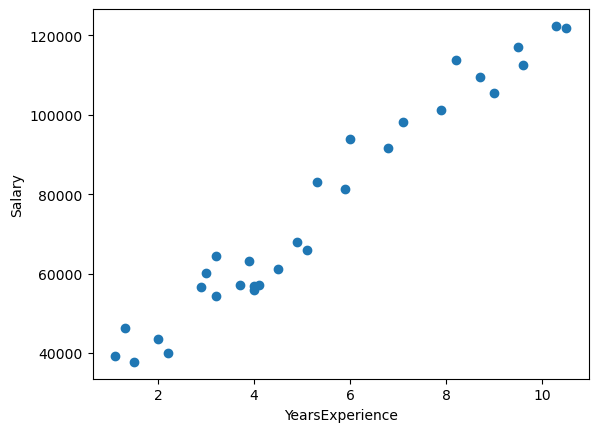

In [11]:
import matplotlib.pyplot as plt #matplotlib is used to plot and visualise data in a chart

plt.scatter(independent, dependent) # passing the independent and dependent valiable to plot
plt.xlabel("YearsExperience",fontsize=10) #labelling X and Y axis with fontzise 10
plt.ylabel("Salary",fontsize=10)
plt.show() #displaying the plot

In [37]:
#splitting the dataset into Train and testing data
from sklearn.model_selection import train_test_split #from sklearn library importing splitting function alone

#passing the independent and dependent dataset, test size 0.3 as arguements to the function
#test set size should be less than traing size so 0.3
X_train,X_test,Y_train,Y_test = train_test_split(independent, dependent, test_size=0.3, random_state=0)

In [38]:
X_test

,YearsExperience
2,1.5
28,10.3
13,4.1
10,3.9
26,9.5
24,8.7
27,9.6
11,4.0
17,5.3


In [33]:
from sklearn.linear_model import LinearRegression #importing the Linear regression library from sklearn
regressor = LinearRegression() # storing the instance of the linearregression class as object in regressor (OOPS)

In [34]:
#TRAINING PHASE
regressor.fit(X_train, X_test)  # Learning phase, the model is created with co-efficients and bias calulated

weight=regressor.coef_ # Fetching the weight- co-effient of the model created

print("Weight of the model={}".format(weight))

bias=regressor.intercept_ # Fetching the bias- intercept of the model created

print("Bias of the model={}".format(bias))

#MODEL Equation ==> 9360.26 X + 26777.39 ==> weight(X) + bias

Weight of the model=[[9360.26128619]]
Bias of the model=[26777.3913412]


In [40]:
#EVALUVATING PHASE
Y_pred=regressor.predict(X_test) # predicting the values using the test set
Y_pred

array([[ 40817.78327049],
       [123188.08258899],
       [ 65154.46261459],
       [ 63282.41035735],
       [115699.87356004],
       [108211.66453108],
       [116635.89968866],
       [ 64218.43648597],
       [ 76386.77615802]])

In [46]:
from sklearn.metrics import r2_score # for r2 score evaluvation importing the function from metrics library

r_score= r2_score(Y_test,Y_pred) # comparing the predicted values and test(Actual) values to calculate R2Score 
r_score # close to 1 ...so Good model !!

0.9740993407213511

In [48]:
import pickle #pickle is to load and save a trained model 
filename = "Salary_prediction_model.sav" # declaring file name
pickle.dump(regressor, open(filename,"wb")) # saving the model by creating a new pickle file

In [54]:
loaded_model = pickle.load(open("Salary_prediction_model.sav","rb")) # now loading the pickle file in read mode 
result = loaded_model.predict([[25]]) # passing a input value to predict

print(result) # got the result from AI - brain

[[260783.92349604]]


C:\Users\z030703\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
